Data from Book by Shmueli et al (2019)

In [1]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

#Scikit & scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from scipy.stats import ttest_rel

#sm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.stats.diagnostic as dg
import statsmodels.graphics.tsaplots as gp
import statsmodels.stats.stattools as st

#torch
import torch
import torch.nn as nn
import torch.utils.data as Data
from torch.autograd import Variable

#captum
from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import NeuronConductance

#dir handling
import os

#Scikit MLP
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression #for lin reg
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor #for MLP
#Dox in https://scikit-learn.org/stable/modules
#/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

#model search
from sklearn.feature_selection import SequentialFeatureSelector

targetDirectory = "C:\\CASES\\PYTPRA"
os.chdir(targetDirectory)

cuda = True
if not torch.cuda.is_available():
    cuda = False
device = torch.device("cuda" if cuda else "cpu")

print("Working directory in use: ", os. getcwd())

C:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Working directory in use:  C:\CASES\PYTPRA


In [2]:
mySEED=2023
#helper fct
def set_seed_everywhere(seed, cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed_all(seed)    
        
set_seed_everywhere(mySEED,cuda)

car_df = pd.read_csv('ToyotaCorolla.csv') 

# select the suggested variables
selected_var = ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
                'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
                'Powered_Windows', 'Sport_Model', 'Tow_Bar']
car_df = car_df[selected_var]

# convert the categorical data into dummy variables
categorical_var = ['Fuel_Type']
car_df = pd.get_dummies(car_df, columns=['Fuel_Type'], drop_first=True)

# separate out predictors and response variables
X_df = car_df.drop(columns=['Price'])
Y_df = car_df[ ['Price'] ]

# normalize the data, scale each attribute on the input vector X to [0, 1] 
scaleInput = MinMaxScaler()
scaleOutput = MinMaxScaler()
X = scaleInput.fit_transform(X_df)
y = scaleOutput.fit_transform(Y_df)

# partition data & establish benchmark model, note that seed is under control
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=mySEED)

print("Dimensions of data are (note that we are working on scaled data)")
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

Dimensions of data are (note that we are working on scaled data)
(1148, 16) (288, 16) (1148, 1) (288, 1)


In [3]:
###############################################################################
#   LinReg Statsmodels
###############################################################################

X_train_temp = sm.add_constant(X_train)
car_linreg_sm = sm.OLS(y_train, X_train_temp)#reverse order of args
car_linreg_sm_results = car_linreg_sm.fit(cov_type='HAC',cov_kwds={'maxlags':1})
print(car_linreg_sm_results.summary())

X_fc = X_valid
X_fc = sm.add_constant(X_fc)
y_fc = car_linreg_sm_results.predict(X_fc)#do not overwrite X_valid

print("\nREG: R squared on training data")
print(round(car_linreg_sm_results.rsquared,3))
print("\n")
print("REG: R squared on test data")
print(round(r2_score(y_valid, y_fc),3))

print("\n--------------RESET - TEST------------------------------")
reset = dg.linear_reset(car_linreg_sm_results, power = 4, test_type = 'fitted', use_f = True, )
print("\nRamsey RESET test with H0: Correct specs \n ")
print("F Statistic: ", np.round(reset.fvalue, 4))
print("P Value: ", np.round(reset.pvalue, 4))
#logic: with Rsq close to 100 percent the linear function is in question, not the X

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     355.4
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        11:20:11   Log-Likelihood:                 1999.8
No. Observations:                1148   AIC:                            -3966.
Df Residuals:                    1131   BIC:                            -3880.
Df Model:                          16                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3158      0.023     13.678      0.0


--------------BP - TEST------------------------------
Breusch- Pagan Test-Statistik: 2.463017486006868e-33
Test auf Normalverteilung der Residuen: 


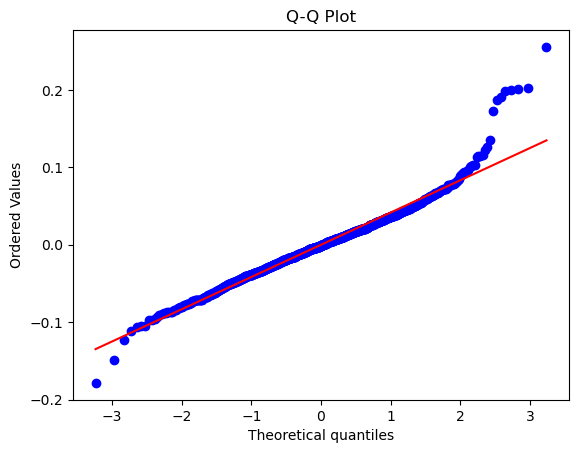

In [4]:
print("\n--------------BP - TEST------------------------------")#H0: Homo
#bp requires normal resis, hence check it
#BUT best is to use White below
bp_test_statistic, bp_p_value, _, _ = dg.het_breuschpagan(car_linreg_sm_results.resid, X_train_temp)
print("Breusch- Pagan Test-Statistik: " + str(bp_p_value))
print("Test auf Normalverteilung der Residuen: ")
stats.probplot(car_linreg_sm_results.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

In [5]:
print("\n--------------WHITE - TEST------------------------------")#H0: Homo
white_test_statistic, white_p_value, _, _ = dg.het_white(car_linreg_sm_results.resid, X_train_temp)
print("White Test-Statistik: " + str(white_p_value))


--------------WHITE - TEST------------------------------
White Test-Statistik: 1.4700619035142286e-73



--------------AUTOCORR - TEST------------------------------


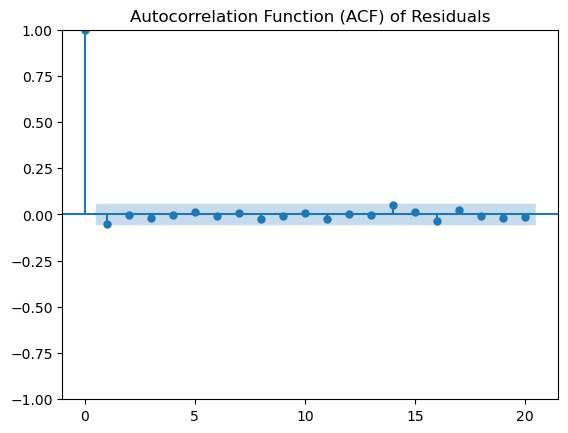

Durbin-Watson Test-Statistik: 2.107243418948138


In [6]:
print("\n--------------AUTOCORR - TEST------------------------------")
#not sensible here
residuals = car_linreg_sm_results.resid
gp.plot_acf(residuals, lags=20)
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.show()  

dw = st.durbin_watson(car_linreg_sm_results.resid)
print("Durbin-Watson Test-Statistik: " + str(dw))

In [7]:
#sufficient to correct hetero
car_linreg_sm_results_hc = car_linreg_sm.fit(cov_type='HC0')
print(car_linreg_sm_results_hc.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     358.4
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        11:20:11   Log-Likelihood:                 1999.8
No. Observations:                1148   AIC:                            -3966.
Df Residuals:                    1131   BIC:                            -3880.
Df Model:                          16                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3158      0.023     13.503      0.0

In [8]:
#automated search for lin regressors
model = LinearRegression()

sfs = SequentialFeatureSelector(model, scoring = "r2")
sfs.fit(X_train_temp, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), scoring='r2')

In [9]:
sfs_columns = sfs.get_support()
print(sfs_columns)
#shows you which should be used = True

[False  True  True  True False False  True False  True False  True False
  True  True False False False]


In [10]:
###############################################################################
#   Data & Model Prep Pytorch
###############################################################################
#motivated by RESET we use richer model to explore
myHIDDENone = 11 #we have 16 dim input + 1 out = 17, two thirds 0f 17 as max number of hiddens = 11
myMAX_EPOCHS = 500 #500 so far net is taken from end
myLEARNING_RATE = 0.01
myBATCH_SIZE = 512 #512 max, nearly half of data, X_train.shape[0] would be full sample, 32 is min

n_input = X_train.shape[1]
n_out = 1

def func_turn_df_into_t(df_arg):
    t_ret = torch.from_numpy(np.array(df_arg))
    t_ret = t_ret.to(torch.float)
    return t_ret

In [11]:
t_X_train = func_turn_df_into_t(X_train)
t_y_train = func_turn_df_into_t(y_train)
t_X_valid = func_turn_df_into_t(X_valid)
t_y_valid = func_turn_df_into_t(y_valid)
print(t_X_train.shape,t_y_train.shape,t_X_valid.shape,t_y_valid.shape)

torch_dataset = Data.TensorDataset(t_X_train, t_y_train)
train_loader = Data.DataLoader(
    dataset=torch_dataset, 
    batch_size=myBATCH_SIZE, 
    shuffle=True, num_workers=0,)#use default

torch.Size([1148, 16]) torch.Size([1148, 1]) torch.Size([288, 16]) torch.Size([288, 1])


In [13]:
###############################################################################
#   MLP Pytorch
###############################################################################

car_mlp_pt = nn.Sequential(nn.Linear(n_input, myHIDDENone),
                      nn.Sigmoid(),#the sublayer has n_hidden outputs (right argument)
                     #this has to be the left argument on the following layer 
                      nn.Linear(myHIDDENone, n_out),
                      nn.Sigmoid())#defines the graph
print(car_mlp_pt)
#linear is a+bX, then follows a hidden layer of n_hidden-s sigmoids, lienarly fed into a single sigmoid output neuron
total_params = sum(p.numel() for p in car_mlp_pt.parameters())
print(f"Total number of parameters in MLP: {total_params:,}")

Sequential(
  (0): Linear(in_features=16, out_features=11, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=11, out_features=1, bias=True)
  (3): Sigmoid()
)
Total number of parameters in CNN: 199


In [12]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(car_mlp_pt.parameters(), lr=myLEARNING_RATE)
losses_train = []
losses_val = []

def generic_training_loop_extended(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u,train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        loss_train_avg = []
        for step, (batch_x, batch_y) in enumerate(train_loader): 
            b_x = Variable(batch_x)
            b_y = Variable(batch_y)
            train_t_p = model(b_x) #all details are in model
            train_loss = loss_fn(train_t_p, b_y) #and the loss function
            loss_train_avg.append(train_loss.item()) 
            optimizer.zero_grad()
            train_loss.backward() 
            optimizer.step()
        with torch.no_grad(): 
            val_t_p = model(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            losses_val.append(val_loss.item()) 
            assert val_loss.requires_grad == False 
        losses_train.append(train_loss.item()) 
        if epoch <= 10 or epoch % 50 == 0:
            print("Epoch", {epoch}, f"Avg. training loss over all batches: {np.average(loss_train_avg[0:step]):.4f}", 
                  f"Validation loss:  {val_loss.item():.4f}",
                  "\n \tLast batch out of", {step}, f"has training loss: {train_loss.item():.4f}")    
    
    return 

generic_training_loop_extended(n_epochs = myMAX_EPOCHS, optimizer = optimizer, model = car_mlp_pt,
                      loss_fn = loss_fn , train_t_u = t_X_train, val_t_u = t_X_valid, 
                      train_t_c = t_y_train, val_t_c = t_y_valid)

Sequential(
  (0): Linear(in_features=16, out_features=11, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=11, out_features=1, bias=True)
  (3): Sigmoid()
)
Epoch {1} Avg. training loss over all batches: 0.1089 Validation loss:  0.0819 
 	Last batch out of {2} has training loss: 0.0891
Epoch {2} Avg. training loss over all batches: 0.0765 Validation loss:  0.0552 
 	Last batch out of {2} has training loss: 0.0563
Epoch {3} Avg. training loss over all batches: 0.0512 Validation loss:  0.0366 
 	Last batch out of {2} has training loss: 0.0399
Epoch {4} Avg. training loss over all batches: 0.0342 Validation loss:  0.0249 
 	Last batch out of {2} has training loss: 0.0291
Epoch {5} Avg. training loss over all batches: 0.0247 Validation loss:  0.0187 
 	Last batch out of {2} has training loss: 0.0166
Epoch {6} Avg. training loss over all batches: 0.0194 Validation loss:  0.0162 
 	Last batch out of {2} has training loss: 0.0150
Epoch {7} Avg. training loss over all batches: 0.0180 Val

In [13]:
#diags of learning process
print("\n Params of Pytorch Net car_mlp_pt")
for name, param in car_mlp_pt.named_parameters():
    print(name, param.shape)

    #summary stats
t_fc = car_mlp_pt(t_X_train).detach().numpy()
t_resi = t_y_train-t_fc
print("\n Mean of Resis: ", torch.mean(t_resi).numpy())
print("\n Last MSE: ", torch.mean(t_resi*t_resi).numpy())
print("\n Stdev of Resis: ", torch.std(t_resi).numpy())


 Params of Pytorch Net car_mlp_pt
0.weight torch.Size([11, 16])
0.bias torch.Size([11])
2.weight torch.Size([1, 11])
2.bias torch.Size([1])

 Mean of Resis:  -0.002658597

 Last MSE:  0.0013630586

 Stdev of Resis:  0.036839824


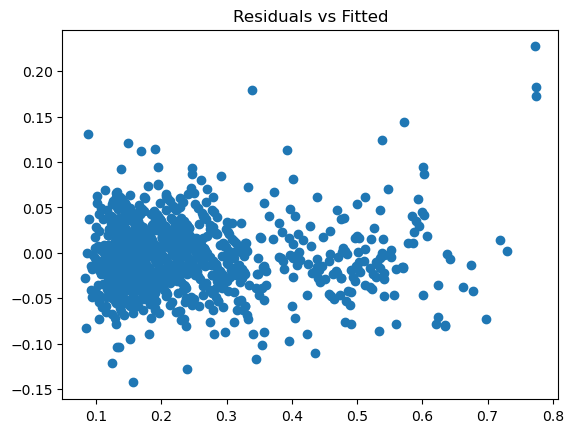

In [14]:
#more diags
plt.scatter(t_fc, t_resi.data.numpy())
plt.title('Residuals vs Fitted')
plt.show()

In [15]:
#############################################################
#              t- Test for resis being centered at zero     #
#############################################################

resi = t_resi.data.numpy()
mean_residuals = np.mean(resi)

# perform t-test 
t_statistic, p_value = stats.ttest_1samp(resi, 0)

# Output results
print(f'Mean of residuals: {mean_residuals}')
print(f't-statistic: {t_statistic}, p-value: {p_value}')

if p_value < 0.05:
    print("The mean of the residuals is significantly different from 0.")
else:
    print("The mean of the residuals is not significantly different from 0.")

Mean of residuals: -0.0026585969608277082
t-statistic: [-2.44515222], p-value: [0.0146287]
The mean of the residuals is significantly different from 0.


In [16]:
#comp of Rsq
print("\nREG: R squared on training data")
print(round(car_linreg_sm_results.rsquared,3))
print("REG: R squared on test data")
print(round(r2_score(y_valid, y_fc),3))
print("\nMLP: R squared on training data")
y_pred = car_mlp_pt(t_X_train).detach().numpy()
print(round(r2_score(y_pred, t_y_train.numpy()),3))
print("MLP: R squared on test data")
y_pred = car_mlp_pt(t_X_valid).detach().numpy()
print(round(r2_score(y_pred, t_y_valid.numpy()),3))


REG: R squared on training data
0.894
REG: R squared on test data
0.867

MLP: R squared on training data
0.912
MLP: R squared on test data
0.875


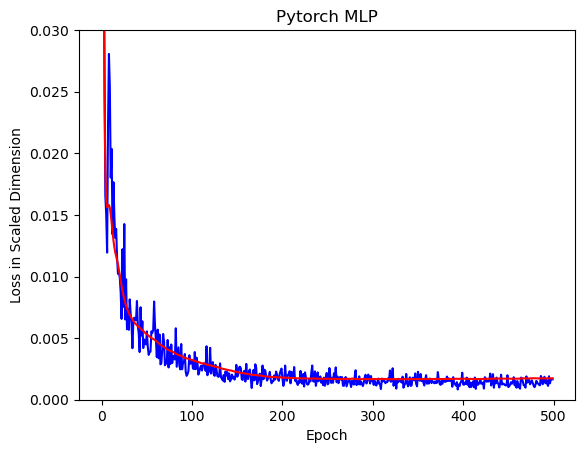

In [17]:
t_ctr = torch.arange(0, myMAX_EPOCHS, step = 1)
t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, losses_train, 'b') # plotting separately 
plt.plot(t_ctr, losses_val, 'r') 
plt.ylabel('Loss in Scaled Dimension')
plt.xlabel('Epoch')
plt.title('Pytorch MLP')
plt.ylim(top = 0.03)
plt.ylim(bottom = 0)
plt.show()

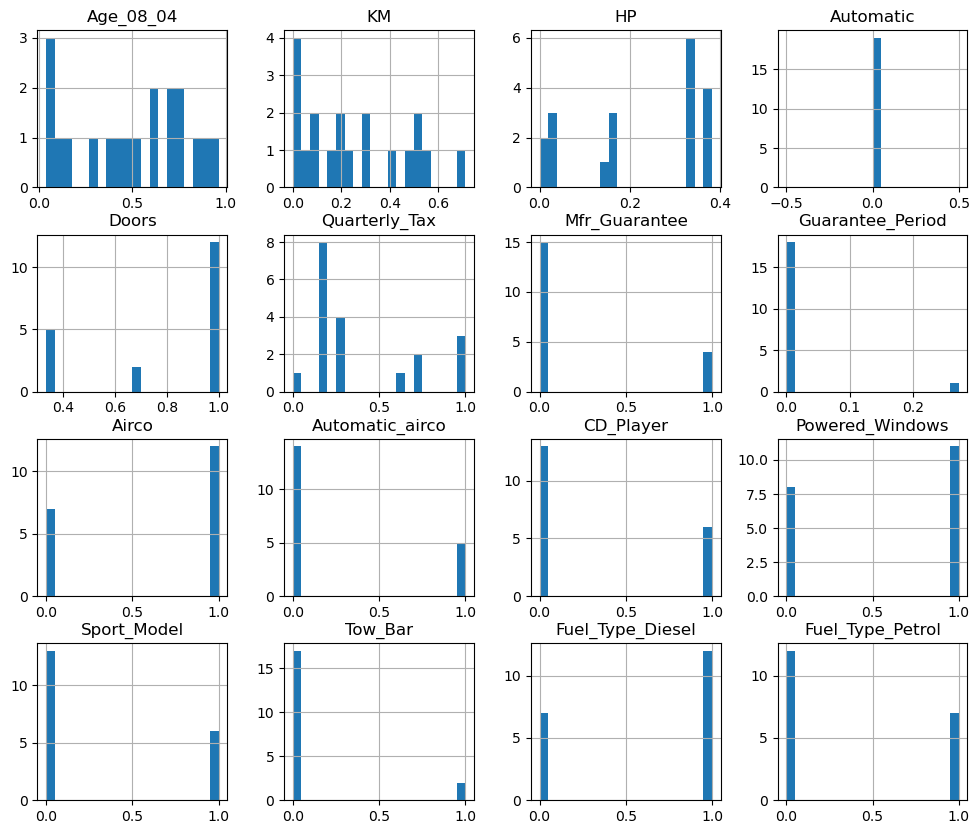

In [18]:
##################################################
#   Featureverteilung von hohen Residuen
##################################################

list_data_outliers = []
list_data_low_residuals = []

for X, y in zip(t_X_train, t_y_train):
    y_pred = car_mlp_pt(X)
    record_residual = y - y_pred
    if abs(record_residual) >= 0.1:  #hurdle by optical inspection of above scatter plot
        list_data_outliers.append((X.detach().numpy(), y.detach().numpy()))

data_dict = {}

for column in X_df.columns:
    data_dict[column] = []
    
for i in range(0, len(data_dict)):
    for outlier_record in list_data_outliers:
        #print(data_dict[X_df.columns[i]])
        data_dict.get(X_df.columns[i]).append(outlier_record[0][i])
        
#df_outliers = pd.DataFrame(list_data_outliers[0], columns=X_df.columns)
df_outliers = pd.DataFrame(data_dict)
df_outliers.hist(figsize=(12, 10), bins=20)
#plt.suptitle('Histograms of High Residual Independent Data')
plt.show()

In [ ]:
#inspect model
ig = IntegratedGradients(car_mlp_pt)#Specifically, integrated gradients
#are defined as the path intergral of the gradients along the straightline path
#see https://arxiv.org/pdf/1703.01365.pdf
ig_input_tensor = t_X_train
ig_input_tensor.requires_grad_()
attr, delta = ig.attribute(ig_input_tensor,target=0, return_convergence_delta=True)
#target class No 0 because we only have one output dimension
attr = attr.detach().numpy()
np.round(attr,2)
importances = np.mean(attr, axis=0)
feature_names = list(X_df.columns)
for i in range(len(feature_names)):
        print(feature_names[i], ": ", '%.3f'%(importances[i]))
        

print("\n Params of Pytorch MLP")
for name, param in car_mlp_pt.named_parameters():
    print(name, param.shape)
    print(name, param.data)

In [ ]:
#permutation of features
def permute_features(data, feature_index):
    shuffled = t_X_valid.clone()
    column_to_shuffle = t_X_valid[:, feature_index]
    shuffled_indices = torch.randperm(column_to_shuffle.size(0))
    shuffled_column = column_to_shuffle[shuffled_indices]
    shuffled[:, feature_index] = shuffled_column
    return shuffled

In [ ]:
r_2_permuted = []
#y_pred = car_mlp_pt(t_X_valid).detach().numpy()
outputs_test = car_mlp_pt(t_X_valid)
predicted_price = [i.item() for i in outputs_test]
baseline = r2_score(t_y_valid,predicted_price)
print(baseline)

In [ ]:
for i in range(len(t_X_valid[0])):
    permuted_validation_data = permute_features(t_X_valid, i)
    car_mlp_pt.eval()
    permuted_predictions = car_mlp_pt(permuted_validation_data)
    predicted_price = [i.item() for i in permuted_predictions]
    r2_permuted = r2_score(t_y_valid,predicted_price)
    r_2_permuted.append(r2_permuted)

In [ ]:
results_feature_importance=pd.DataFrame()
#results_feature_importance["feature"]= df.drop('rating_google',axis=1).columns
results_feature_importance["r_2_permuted"] = r_2_permuted
results_feature_importance["loss_from_permutation"] = baseline - r_2_permuted
results_feature_importance=results_feature_importance.sort_values(by="loss_from_permutation",ascending=False)
results_feature_importance.head(10)
#see that age is again the main driver/factor = first regressor =0th in Python

In [ ]:
#for deployment we save the weights
#saving in default working dir of Jupyter, serialisation
torch.save(car_mlp_pt.state_dict(), "car_mlp_pt.pt")#use pt and not pth! Latter one collides with python path
#then we can load and maybe write a main-style program for batch exe
loaded_model = torch.load("car_mlp_pt.pt", map_location = 'cpu')#avoid default access to GPU

In [ ]:
# Modell initialisieren as in Pytorch
mlp_model = MLPRegressor(max_iter=myMAX_EPOCHS, hidden_layer_sizes=(myHIDDENone), activation='logistic', 
                        solver='adam', batch_size = myBATCH_SIZE,
                        shuffle = True, random_state=mySEED, 
                        verbose = False)#set true if details matter

print(mlp_model.get_params(mlp_model.get_params)) 
#if u want full picture of default and other paras used

# Modell trainieren mit default
mlp_model.fit(X_train, y_train.ravel())
y_fc_scikit = mlp_model.predict(X_train)
print("\n\nREG: R squared on train data SCIKIT")
print(round(r2_score(y_train, y_fc_scikit),3))#Pytorch achieved more on training

In [ ]:
# Modell initialisieren mit Hyperparameter-Tuning, 
##inkludiere Paras, die bei PyTorch genutzt wurden, weil hier scikit
#variiere nur über learning rate and architecture
mlp_model2 = GridSearchCV(mlp_model,
    {
    "hidden_layer_sizes": [(11), (12), (13), (8,6)],
    #"activation":["logistic"], #["identity", "logistic", "tanh", "relu"],
    #"solver":["adam"],#["lbfgs", "sgd", "adam"]
    #"max_iter": [myMAX_EPOCHS],
    "learning_rate_init": [myLEARNING_RATE,(myLEARNING_RATE*10),(myLEARNING_RATE/10)],
    #"random_state": [mySEED],#control this already above
    }, 
    cv=2, #the default is 5-fold cross validation
    #parameter search uses the score function of the estimator to evaluate a parameter setting.
    #with MLP Regressor it is R2
    verbose = 0 #2 = time and R2 reported
)
mlp_model2.fit(X_train, y_train.ravel()) #this executes the grid search

In [ ]:
# Ergebnisse des Hyperparameter-Tuning
#print(pd.DataFrame(mlp_model2.cv_results_))#print if details wanted

# Hyperparameter nach dem Tuning mit Kreuzvalidierung anzeigen
print("Best Score:", mlp_model2.best_score_)
print("Best Params:", mlp_model2.best_params_)

In [ ]:
# Modell explizit betrachten
mlp_model3 = MLPRegressor(max_iter=myMAX_EPOCHS, hidden_layer_sizes=(8,6), activation='logistic', 
                        solver='adam', batch_size = myBATCH_SIZE, learning_rate_init = myLEARNING_RATE*10,
                        shuffle = True, random_state=mySEED, 
                        verbose = False)
mlp_model3.fit(X_train, y_train.ravel())
y_fc_scikit_best = mlp_model3.predict(X_train)

In [ ]:
#i guess that grid search reporta R2 on training set minus hold out! It uses x-fold Cross Vali!
print(mlp_model3.get_params(mlp_model3.get_params)) 
print("\n\nREG: R squared on train data SCIKIT BEST MODEL")
print(round(r2_score(y_train, y_fc_scikit_best),3))#Pytorch achieved more on training

In [ ]:
print("\nXXX DONE XXX")